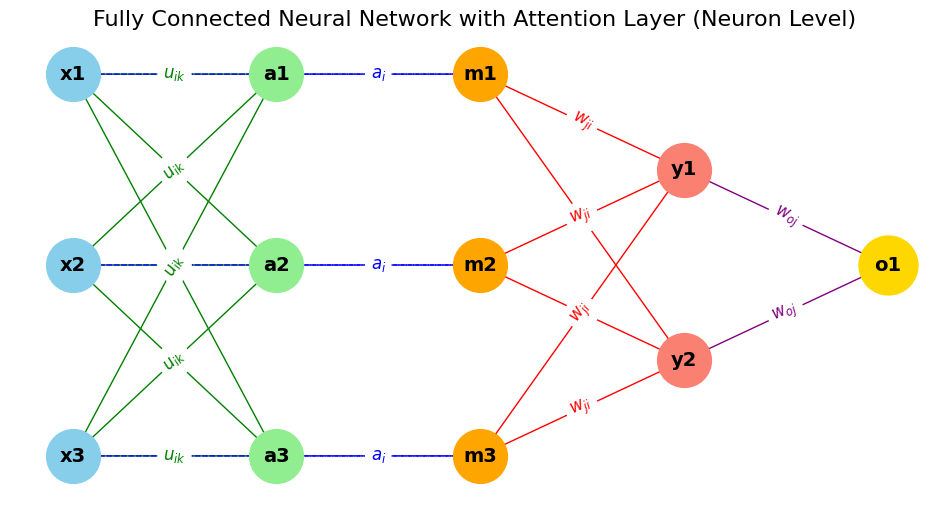

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams.update({'font.size': 12})

G = nx.DiGraph()

# Positions for nodes
pos = {}

# Layers x-coordinates
x_input = 0
x_attention = 2
x_multiply = 4
x_fc = 6
x_output = 8

# Input neurons (3)
input_nodes = ['x1', 'x2', 'x3']
for i, node in enumerate(input_nodes):
    pos[node] = (x_input, 2 - i*2)

# Attention neurons (3)
attention_nodes = ['a1', 'a2', 'a3']
for i, node in enumerate(attention_nodes):
    pos[node] = (x_attention, 2 - i*2)

# Multiply layer (3)
multiply_nodes = ['m1', 'm2', 'm3']  # represents x_i * a_i
for i, node in enumerate(multiply_nodes):
    pos[node] = (x_multiply, 2 - i*2)

# Fully connected layer (2)
fc_nodes = ['y1', 'y2']
for i, node in enumerate(fc_nodes):
    pos[node] = (x_fc, 1 - i*2)

# Output neuron (1)
output_node = 'o1'
pos[output_node] = (x_output, 0)

# Add edges Input -> Attention (fully connected)
for inp in input_nodes:
    for att in attention_nodes:
        G.add_edge(inp, att, weight='u_{ik}')

# Add edges Attention -> Multiply (one-to-one)
for a, m in zip(attention_nodes, multiply_nodes):
    G.add_edge(a, m, label='a_i')

# Add edges Input -> Multiply (one-to-one)
for x, m in zip(input_nodes, multiply_nodes):
    G.add_edge(x, m, label='x_i')

# Add edges Multiply -> Fully connected (fully connected)
for m in multiply_nodes:
    for y in fc_nodes:
        G.add_edge(m, y, weight='w_{ji}')

# Add edges Fully connected -> Output
for y in fc_nodes:
    G.add_edge(y, output_node, weight='w_{oj}')

# Draw the graph
plt.figure(figsize=(12,6))
nx.draw_networkx_nodes(G, pos, nodelist=input_nodes, node_color='skyblue', node_size=1500)
nx.draw_networkx_nodes(G, pos, nodelist=attention_nodes, node_color='lightgreen', node_size=1500)
nx.draw_networkx_nodes(G, pos, nodelist=multiply_nodes, node_color='orange', node_size=1500)
nx.draw_networkx_nodes(G, pos, nodelist=fc_nodes, node_color='salmon', node_size=1500)
nx.draw_networkx_nodes(G, pos, nodelist=[output_node], node_color='gold', node_size=1800)

# Labels
labels = {n: n for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=14, font_weight='bold')

# Edges Input -> Attention
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v in G.edges() if u in input_nodes and v in attention_nodes], arrowstyle='-|>', arrowsize=20, edge_color='green')
# Edges Attention -> Multiply
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v in G.edges() if u in attention_nodes and v in multiply_nodes], style='dashed', edge_color='blue', arrowsize=20)
# Edges Input -> Multiply
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v in G.edges() if u in input_nodes and v in multiply_nodes], style='dashed', edge_color='blue', arrowsize=20)
# Edges Multiply -> FC
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v in G.edges() if u in multiply_nodes and v in fc_nodes], arrowstyle='-|>', arrowsize=20, edge_color='red')
# Edges FC -> Output
nx.draw_networkx_edges(G, pos, edgelist=[(u,v) for u,v in G.edges() if u in fc_nodes and v == output_node], arrowstyle='-|>', arrowsize=20, edge_color='purple')

# Edge labels for weights u_ik on Input->Attention
edge_labels_1 = {(u,v): r'$u_{ik}$' for u,v in G.edges() if u in input_nodes and v in attention_nodes}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_1, font_color='green', font_size=12)

# Edge labels for weights w_ji on Multiply->FC
edge_labels_2 = {(u,v): r'$w_{ji}$' for u,v in G.edges() if u in multiply_nodes and v in fc_nodes}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_2, font_color='red', font_size=12)

# Edge labels for weights w_oj on FC->Output
edge_labels_3 = {(u,v): r'$w_{oj}$' for u,v in G.edges() if u in fc_nodes and v == output_node}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_3, font_color='purple', font_size=12)

# Edge labels for attention and input on Attention->Multiply and Input->Multiply
edge_labels_4 = {(u,v): r'$a_i$' for u,v in G.edges() if u in attention_nodes and v in multiply_nodes}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_4, font_color='blue', font_size=12)

edge_labels_5 = {(u,v): r'$x_i$' for u,v in G.edges() if u in input_nodes and v in multiply_nodes}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_5, font_color='blue', font_size=12)

plt.title('Fully Connected Neural Network with Attention Layer (Neuron Level)', fontsize=16)
plt.axis('off')
plt.show()
